In [1]:
import pandas as pd
import numpy as np
import random
import time

In [2]:
%matplotlib notebook

<IPython.core.display.Javascript object>


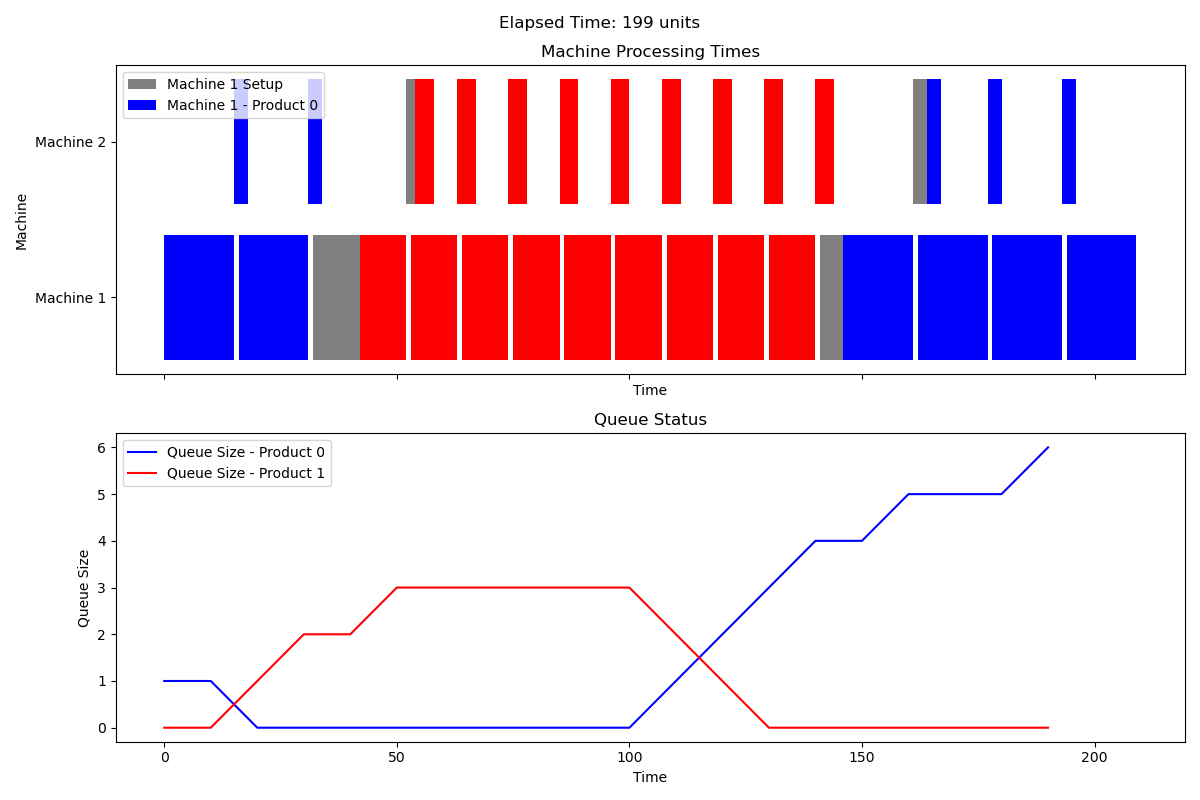

In [3]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np
from IPython.display import HTML
import os

class Machine:
    def __init__(self, processing_times, setup_times):
        self.processing_times = processing_times
        self.setup_times = setup_times
        self.current_product = None
        self.finish_time = 0
        self.busy = False
        self.event_log = []

    def process(self, product, current_time):
        self.busy = True
        setup_time = 0
        if self.current_product is not None:
            setup_time = self.setup_times[self.current_product][product]
        start_time = current_time + setup_time
        self.finish_time = start_time + self.processing_times[product]
        self.event_log.append(('setup', current_time, start_time, setup_time, product, self.current_product))
        self.event_log.append((product, start_time, self.finish_time))
        self.current_product = product  # Update current_product after setup calculation
        return self.finish_time
    
    def update(self, current_time):
        if current_time >= self.finish_time:
            self.busy = False
            finished_product = self.current_product
            # Do not reset current_product here; let it change when a new product starts processing
            return finished_product
        return None

    def print_event_log(self):
        for event in self.event_log:
            if event[0] == 'setup':
                print(f"Setup for Product {event[4]} after {event[5]}: from {event[1]} to {event[2]} (Setup time: {event[3]} sec)")
            else:
                print(f"Product {event[0]}: Processed from {event[1]} to {event[2]}")


class ProductionLine:
    def __init__(self, machine1_times, machine1_setups, machine2_times, machine2_setups, arrival_rate):
        self.machine1 = Machine(machine1_times, machine1_setups)
        self.machine2 = Machine(machine2_times, machine2_setups)
        self.arrival_rate = arrival_rate
        self.queue = []
        self.next_arrival = 0
        self.finished_products = [0, 0]
        self.queue_log = []  # To log queue status over time
        
    def add_item(self, product, current_time):
        self.queue.append((product, current_time))
        queue_size_0 = sum(1 for p, _ in self.queue if p == 0)
        queue_size_1 = sum(1 for p, _ in self.queue if p == 1)
        self.queue_log.append(((queue_size_0, queue_size_1), current_time))  # Log queue size per product and time

    def run_step(self, current_time):
        if self.queue and not self.machine1.busy:
            product, _ = self.queue.pop(0)
            self.machine1.process(product, current_time)

        if not self.machine2.busy and self.machine1.busy and current_time >= self.machine1.finish_time:
            finished_product = self.machine1.update(current_time)
            if finished_product is not None:
                self.machine2.process(finished_product, current_time)

        finished_product = self.machine2.update(current_time)
        if finished_product is not None:
            self.finished_products[finished_product] += 1

        if current_time >= self.next_arrival:
            self.add_item(0 if self.finished_products[0] <= self.finished_products[1] else 1, current_time)
            self.next_arrival += self.arrival_rate

def animate(i, production_line, gantt_ax, queue_ax):
    production_line.run_step(i)
    # Plot queue status on the lower subplot
    queue_times = [time for _, time in production_line.queue_log]
    queue_sizes_0 = [size[0] for size, _ in production_line.queue_log]
    queue_sizes_1 = [size[1] for size, _ in production_line.queue_log]
    queue_ax.clear()
    queue_ax.plot(queue_times, queue_sizes_0, label='Queue Size - Product 0', color='blue')
    queue_ax.plot(queue_times, queue_sizes_1, label='Queue Size - Product 1', color='red')
    queue_ax.set_title('Queue Status')
    queue_ax.set_xlabel('Time')
    queue_ax.set_ylabel('Queue Size')
    queue_ax.legend(loc='upper left')

   # Initialize a set to track labels
    used_labels = set()

    # Inside the plotting loop
    for machine_idx, machine in enumerate([production_line.machine1, production_line.machine2]):
        for event in machine.event_log:
            start, end = event[1], event[2]
            color = 'blue' if event[0] == 0 else 'red'
            label = None  # Default to no label
            if event[0] == 'setup':
                color = 'grey'
                label_text = f'Machine {machine_idx + 1} Setup'
                if label_text not in used_labels and i == 0:
                    label = label_text
                    used_labels.add(label_text)
            else:
                label_text = f'Machine {machine_idx + 1} - Product {event[0]}'
                if label_text not in used_labels and i == 0:
                    label = label_text
                    used_labels.add(label_text)
            gantt_ax.broken_barh([(start, end - start)], (machine_idx, 0.8), facecolors=color, label=label)

    # Setting static elements (will not clear on every frame)
    if i == 0:
        handles, labels = gantt_ax.get_legend_handles_labels()
        by_label = dict(zip(labels, handles))
        gantt_ax.legend(by_label.values(), by_label.keys())
        gantt_ax.set_yticks([0.4, 1.4])
        gantt_ax.set_yticklabels(['Machine 1', 'Machine 2'])
        gantt_ax.set_title('Machine Processing Times')
        gantt_ax.set_xlabel('Time')
        gantt_ax.set_ylabel('Machine')
        gantt_ax.legend(loc='upper left')

    plt.tight_layout()
    plt.suptitle(f'Elapsed Time: {i} units')


fig, (gantt_ax, queue_ax) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
# Create ProductionLine instance
production_line = ProductionLine({0: 15, 1: 10}, {None: {0: 5, 1: 3}, 0: {0: 0, 1: 10}, 1: {0: 5, 1: 0}},
                                 {0: 3, 1: 4}, {None: {0: 0, 1: 0}, 0: {0: 0, 1: 2}, 1: {0: 3, 1: 0}}, 10)

ani = FuncAnimation(fig, animate, frames=np.arange(0, 200, 1), fargs=(production_line, gantt_ax, queue_ax), interval=100,repeat=False)
plt.show()


In [ ]:
#frames=np.arange(0, 20, 1): This sets the frames to be integers from 0 to 19. The function animate is called with each of these integers (i) sequentially.
#fargs=(production_line, gantt_ax, queue_ax): These are additional arguments passed to the animate function.
#interval=100: This sets the interval between frames to 100 milliseconds.

In [ ]:
#Next steps
# 1) Introduce a demand forecast into the state space and reward it for meeting future excess demand
# 2) See if it can switch demand patterns quickly 
# 3) Q-learning implementaion to achive the same result
# 4) Write a LP program of this